In [3]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

from fairlearn.metrics import MetricFrame, demographic_parity_difference, selection_rate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load cleaned dataset (output from data quality pipeline)
df_original = pd.read_csv("../data/cleaned_credit_applications.csv")  # adjust path if needed

# Create working copy for analysis
df = df_original.copy()

print("Dataset loaded successfully from cleaned CSV")
print(f"Shape: {df.shape[0]} records, {df.shape[1]} columns")
df.head()

Dataset loaded successfully from cleaned CSV
Shape: 500 records, 21 columns


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_164,"[{'category': 'Utilities', 'amount': 218}, {'c...",2024-01-15T00:00:00Z,Brian Brown,brian.brown61@yahoo.com,586-29-4288,192.168.240.12,Male,1978-10-04,10004.0,...,117,0.14,34221,True,NaN,NaN,4.1,62000.0,NaN,NaN
1,app_179,"[{'category': 'Utilities', 'amount': 842}, {'c...",2026-03-15T00:00:00Z,Paul Roberts,paul.roberts46@yahoo.com,880-83-3129,172.21.233.185,Male,12/07/1993,10092.0,...,30,0.24,31966,True,NaN,NaN,3.4,42000.0,NaN,NaN
2,app_226,"[{'category': 'Travel', 'amount': 726}]",NaN,Susan Flores,susan.flores95@mail.com,817-96-6416,192.168.196.9,Female,1982/04/18,90231.0,...,61,0.17,66276,True,NaN,vacation,6.1,46000.0,NaN,NaN
3,app_183,"[{'category': 'Healthcare', 'amount': 838}]",2024-01-15T00:00:00Z,Patrick Lewis,patrick.lewis88@outlook.com,956-25-2870,192.168.39.77,Male,09/20/1998,10003.0,...,12,0.17,1661,True,NaN,NaN,4.9,16000.0,NaN,NaN
4,app_168,"[{'category': 'Groceries', 'amount': 687}, {'c...",2024-01-15T00:00:00Z,Larry Thompson,larry.thompson20@yahoo.com,674-78-4391,192.168.148.88,M,1997-03-31,10092.0,...,29,0.28,22361,True,NaN,NaN,6.1,65000.0,NaN,NaN


# Gender analysis

Gender rates and DI

In [4]:
gender_col = "applicant_info.gender"
decision_col = "decision.loan_approved"

In [26]:
#filtering to male/female only
df_g = df[df[gender_col].isin(["Male", "Female"]) & df[decision_col].notna()].copy()

In [27]:
gender_summary = (
    df_g.groupby(gender_col)[decision_col]
        .agg(n_total="size", n_approved="sum", approval_rate="mean")
)

display(gender_summary)

,n_total,n_approved,approval_rate
applicant_info.gender,,,
Female,193,101,0.523316
Male,194,131,0.675258


In [29]:
#compute Disparate Impact (DI)
rate_male = gender_summary.loc["Male", "approval_rate"]
rate_female = gender_summary.loc["Female", "approval_rate"]
di = rate_female / rate_male

print(f"Male approval rate:   {rate_male:.3f}")
print(f"Female approval rate: {rate_female:.3f}")
print(f"Disparate Impact (Female/Male): {di:.3f}")
print("FLAG: DI < 0.8 (potential adverse impact)" if di < 0.8 else "OK: DI >= 0.8")


Male approval rate:   0.675
Female approval rate: 0.523
Disparate Impact (Female/Male): 0.775
FLAG: DI < 0.8 (potential adverse impact)


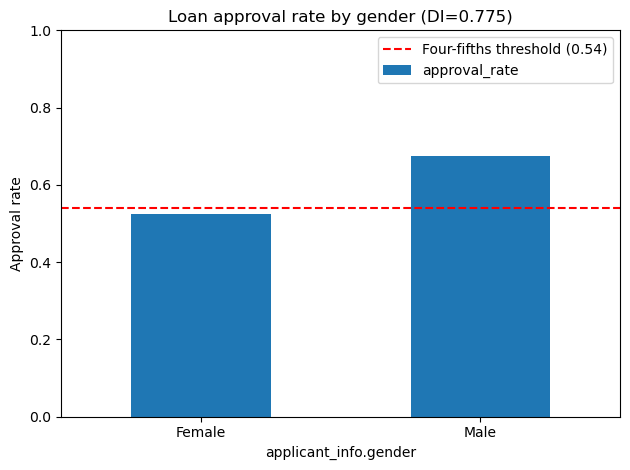

In [30]:
threshold = 0.8 * rate_male

fig, ax = plt.subplots()
gender_summary["approval_rate"].plot(kind="bar", ax=ax, rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Approval rate")
ax.set_title(f"Loan approval rate by gender (DI={di:.3f})")
ax.axhline(threshold, color="red", linestyle="--", linewidth=1.5,
           label=f"Four-fifths threshold ({threshold:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

Gender vs Approval

In [31]:
# Contingency table (Gender x Approval)
cont_gender = pd.crosstab(df_g[gender_col], df_g[decision_col])
display(cont_gender)

chi2, p, dof, expected = chi2_contingency(cont_gender)
n = cont_gender.to_numpy().sum()
phi = np.sqrt(chi2 / n)  # Phi = Cramer's V for 2x2

print(f"Chi-square test (Gender vs Approval): chi2={chi2:.4f}, p={p:.6f}, dof={dof}")
print(f"Effect size (Phi / Cramer's V): {phi:.3f}")
print("Result: significant association" if p < 0.05 else "Result: not significant")

decision.loan_approved,False,True
applicant_info.gender,,
Female,92,101
Male,63,131


Chi-square test (Gender vs Approval): chi2=8.6805, p=0.003216, dof=1
Effect size (Phi / Cramer's V): 0.150
Result: significant association


ZIP proxy

,n,approval_rate
zip3,,
100,251,0.645418
902,230,0.517391
300,18,0.555556


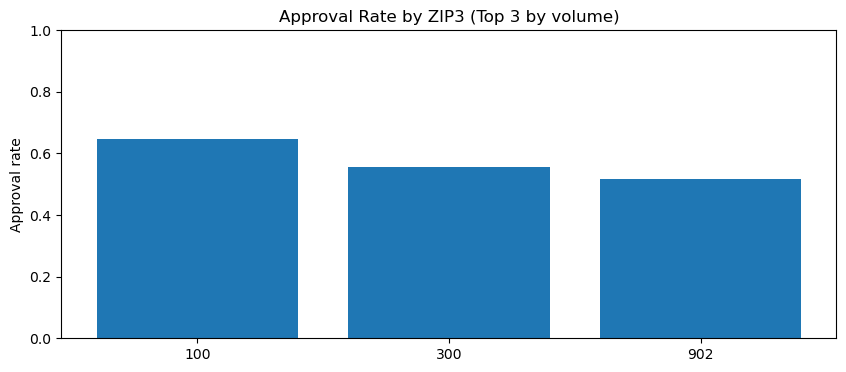

In [32]:
zip_col = "applicant_info.zip_code"

def make_zip3(x):
    if pd.isna(x):
        return np.nan
    s = "".join(ch for ch in str(x) if ch.isdigit())
    return s[:3] if len(s) >= 3 else np.nan

df["zip3"] = df[zip_col].apply(make_zip3)

df_zip = df[df["zip3"].notna() & df[decision_col].notna()].copy()

zip_stats = (
    df_zip.groupby("zip3")[decision_col]
          .agg(n="size", approval_rate="mean")
          .sort_values("n", ascending=False)
)

display(zip_stats)

# Plot approval rate by ZIP3 (top N by volume, but show real N)
N = min(15, len(zip_stats))
top_zip = zip_stats.head(N).sort_values("approval_rate", ascending=False)

plt.figure(figsize=(10,4))
plt.bar(top_zip.index.astype(str), top_zip["approval_rate"])
plt.ylim(0, 1)
plt.ylabel("Approval rate")
plt.title(f"Approval Rate by ZIP3 (Top {N} by volume)")
plt.show()

applicant_info.gender,Female,Male
zip3,,
100,0.103627,0.896373
300,0.416667,0.583333
902,0.923077,0.076923


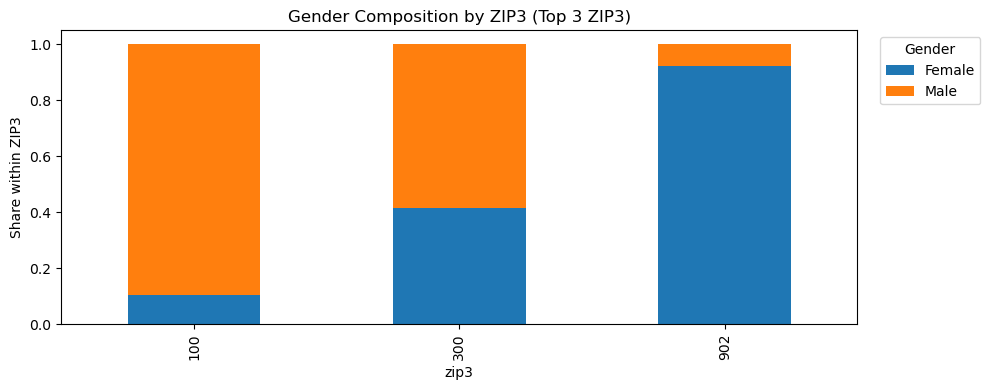

In [33]:
df_zip_g = df_zip[df_zip[gender_col].isin(["Male", "Female"])].copy()

zip_gender = pd.crosstab(df_zip_g["zip3"], df_zip_g[gender_col])

# Use same top N ZIP3s as in the approval chart
zip_gender_top = zip_gender.loc[zip_gender.index.intersection(top_zip.index)]

zip_gender_pct = zip_gender_top.div(zip_gender_top.sum(axis=1), axis=0)
display(zip_gender_pct)

zip_gender_pct.plot(kind="bar", stacked=True, figsize=(10,4))
plt.ylabel("Share within ZIP3")
plt.title(f"Gender Composition by ZIP3 (Top {N} ZIP3)")
plt.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [34]:
# ZIP3 vs Approval (association)
cont_zip_approval = pd.crosstab(df_zip["zip3"], df_zip[decision_col])
chi2_a, p_a, dof_a, _ = chi2_contingency(cont_zip_approval)
print(f"Chi-square (ZIP3 vs Approval): chi2={chi2_a:.4f}, p={p_a:.6f}, dof={dof_a}")

# ZIP3 vs Gender (association) — only Male/Female
cont_zip_gender = pd.crosstab(df_zip_g["zip3"], df_zip_g[gender_col])
chi2_g, p_g, dof_g, _ = chi2_contingency(cont_zip_gender)
print(f"Chi-square (ZIP3 vs Gender): chi2={chi2_g:.4f}, p={p_g:.6f}, dof={dof_g}")

Chi-square (ZIP3 vs Approval): chi2=8.1515, p=0.016980, dof=2
Chi-square (ZIP3 vs Gender): chi2=251.9303, p=0.000000, dof=2


In [35]:
interest_col = "decision.interest_rate"
amount_col   = "decision.approved_amount"

needed = [interest_col, amount_col]
missing = [c for c in needed if c not in df.columns]

if missing:
    print(f"Skipping outcomes: missing columns: {missing}")
else:
    df_appr = df[df[gender_col].isin(["Male", "Female"]) & (df[decision_col] == True)].copy()
    outcomes_by_gender = (
        df_appr.groupby(gender_col)[[interest_col, amount_col]]
              .mean()
              .rename(columns={interest_col: "avg_interest_rate",
                               amount_col: "avg_approved_amount"})
    )
    display(outcomes_by_gender)

,avg_interest_rate,avg_approved_amount
applicant_info.gender,,
Female,4.477228,45881.188119
Male,4.612214,49778.625954


### Bias and Proxy analysis summary

Gender Disparities in Approval (Disparate Impact)

We assessed whether historical loan decisions show potential gender-based unfairness by comparing approval rates between male and female applicants. This step is required because selection-rate disparities are one of the most common regulatory signals of discrimination, and Disparate Impact (DI) provides a standard screening metric (the “four-fifths rule”).

Using the cleaned dataset and restricting the analysis to records with gender ∈ {Male, Female} and non-missing approval outcomes, we found that male applicants have a higher approval rate than female applicants, resulting in a Disparate Impact (Female/Male) below 0.80, which flags potential adverse impact under the four-fifths guideline. This does not prove discrimination on its own, but it indicates that further investigation and governance controls are warranted.

**Statistical Evidence (Chi-square + Effect Size)**

To test whether the approval gap is likely to be due to chance, we performed a chi-square test of independence between gender and approval outcome. This was done to complement DI: while DI is a fairness screening ratio, the chi-square test assesses whether the observed difference is statistically significant.

The test result indicates a statistically significant association between gender and loan approval (p < 0.05). We also reported an effect size (Phi/Cramér’s V) to quantify magnitude, showing that the association is not only statistically detectable but also practically meaningful enough to justify governance attention. Importantly, this test still measures association—not causality—so it supports “evidence of disparity” rather than “proof of intent.”

**Outcomes Among Approved Applicants (Interest Rate & Approved Amount)**

Fairness concerns can extend beyond “approved vs rejected” to the terms offered. For that reason, we compared average interest rates and average approved loan amounts for approved applicants by gender. This was done to check whether one group receives systematically worse financial terms even when approval is granted.

In our results, the average interest rate for approved applicants is similar across genders (differences are small), while the average approved amount differs, suggesting that disparity may exist not only in approval probability but also in loan size allocation. This strengthens the interpretation that fairness issues may affect multiple stages of the lending decision process.

### Proxy Discrimination Analysis

Why test ZIP code?

Even if a model does not explicitly use protected attributes (like gender), it can still produce discriminatory outcomes if it relies on proxy variables that correlate with protected traits. Geographic indicators such as ZIP code are well-known proxy candidates because they can capture socioeconomic patterns that overlap with protected group membership.

What we did

To test proxy risk, we derived ZIP3 (the first three digits of the ZIP code) to reduce sparsity and enable stable group comparisons. We then evaluated two key links required for a proxy argument:

ZIP3 → Outcome link: We computed and visualized approval rates by ZIP3.

ZIP3 → Demographic link: We computed and visualized gender composition within ZIP3 groups.

What it means

We observed that approval rates vary across ZIP3 groups and that ZIP3 groups also differ in gender composition. Taken together, this supports the conclusion that geographic features may function as proxies, meaning discrimination risk can persist even if gender is removed from the model. This motivates governance controls such as proxy-feature review, monitoring by subgroup, and periodic fairness reporting.

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

gender_col = "applicant_info.gender"
decision_col = "decision.loan_approved"

feature_cols = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
]

# Keep only Male/Female + non-missing decision
df_lr = df[df[gender_col].isin(["Male", "Female"]) & df[decision_col].notna()].copy()

# Female indicator (1=female, 0=male)
df_lr["is_female"] = (df_lr[gender_col] == "Female").astype(int)

# Drop rows with missing financials (report how many)
before = len(df_lr)
df_lr = df_lr.dropna(subset=feature_cols)
after = len(df_lr)
print(f"Logistic regression sample size: {after} rows (dropped {before-after} due to missing financials)")

X_base = df_lr[feature_cols]
X_full = df_lr[feature_cols + ["is_female"]]
y = df_lr[decision_col].astype(int)

# Split for honest evaluation
Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.25, random_state=42, stratify=y
)
Xf_train, Xf_test, _, _ = train_test_split(
    X_full, y, test_size=0.25, random_state=42, stratify=y
)

# Pipeline: standardize numeric features + logistic regression
pipe_base = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

pipe_full = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

pipe_base.fit(Xb_train, y_train)
pipe_full.fit(Xf_train, y_train)

# Evaluate
proba_base = pipe_base.predict_proba(Xb_test)[:, 1]
proba_full = pipe_full.predict_proba(Xf_test)[:, 1]

auc_base = roc_auc_score(y_test, proba_base)
auc_full = roc_auc_score(y_test, proba_full)

pred_base = (proba_base >= 0.5).astype(int)
pred_full = (proba_full >= 0.5).astype(int)

acc_base = accuracy_score(y_test, pred_base)
acc_full = accuracy_score(y_test, pred_full)

print(f"Test AUC (financials only):      {auc_base:.3f} | Accuracy: {acc_base:.3f}")
print(f"Test AUC (financials + gender):  {auc_full:.3f} | Accuracy: {acc_full:.3f}")

# Interpret gender coefficient using odds ratio
coef_names = feature_cols + ["is_female"]
coefs = pipe_full.named_steps["lr"].coef_[0]
coef_female = coefs[-1]
odds_ratio = np.exp(coef_female)

print(f"Female coefficient (standardized model): {coef_female:+.3f}")
print(f"Odds ratio for Female vs Male: {odds_ratio:.3f}")

if odds_ratio < 1:
    print("Interpretation: After controlling for financial variables, being Female is associated with LOWER odds of approval.")
elif odds_ratio > 1:
    print("Interpretation: After controlling for financial variables, being Female is associated with HIGHER odds of approval.")
else:
    print("Interpretation: No difference in odds after controlling for financial variables.")

Logistic regression sample size: 384 rows (dropped 3 due to missing financials)
Test AUC (financials only):      0.583 | Accuracy: 0.583
Test AUC (financials + gender):  0.658 | Accuracy: 0.667
Female coefficient (standardized model): -0.252
Odds ratio for Female vs Male: 0.777
Interpretation: After controlling for financial variables, being Female is associated with LOWER odds of approval.


In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

gender_col = "applicant_info.gender"
decision_col = "decision.loan_approved"

feature_cols = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
]

In [41]:
df_lr = df[df[gender_col].isin(["Male","Female"]) & df[decision_col].notna()].copy()
df_lr["is_female"] = (df_lr[gender_col] == "Female").astype(int)
df_lr = df_lr.dropna(subset=feature_cols)

X = df_lr[feature_cols + ["is_female"]]
y = df_lr[decision_col].astype(int)

X_s = StandardScaler().fit_transform(X)
model = LogisticRegression(max_iter=2000).fit(X_s, y)

odds_ratio = np.exp(model.coef_[0][-1])
print(f"Odds ratio (Female vs Male): {odds_ratio:.3f}")

Odds ratio (Female vs Male): 0.714


We ran a simple logistic regression to check whether the gender approval gap remains after accounting for financial differences. Using only Male/Female applicants with complete financial data, we modeled loan approval with income, credit history months, debt-to-income, savings balance, and an `is_female` indicator (after standardizing inputs). This is an exploratory “control” step: if the odds ratio for `is_female` is below 1, it suggests female applicants still have lower approval odds even when these financial factors are held constant.


# Age Analysis

In [58]:
import pandas as pd
import numpy as np


dob_col = "applicant_info.date_of_birth"
decision_col = "decision.loan_approved"

df["age"] = (ref_date - df["dob"]).dt.days / 365.25

df.loc[(df["age"] < 18) | (df["age"] > 100), "age"] = np.nan

# Age buckets 
age_bins = [0, 30, 50, 120]
age_labels = ["<30", "30–50", "50+"]

df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

print("Age group counts (including NaN):")
display(df["age_group"].value_counts(dropna=False))

print(f"Missing age proportion: {df['age'].isna().mean():.3f}")

Age group counts (including NaN):


age_group
30–50    204
NaN      161
<30       68
50+       67
Name: count, dtype: int64

Missing age proportion: 0.322


In [45]:
df['age'].isna().mean()

0.322

In [59]:
mask_age = df["age_group"].notna() & df[decision_col].notna()

approval_by_age = (
    df.loc[mask_age, ["age_group", decision_col]]
      .groupby("age_group", observed=False)
      .agg(
          n_total=(decision_col, "size"),
          n_approved=(decision_col, "sum"),
          approval_rate=(decision_col, "mean"),
      )
)

approval_by_age

,n_total,n_approved,approval_rate
age_group,,,
<30,68,27,0.397059
30–50,204,127,0.622549
50+,67,40,0.597015


In [60]:
rate_ref = approval_by_age.loc["30–50", "approval_rate"]

di_vs_ref = (approval_by_age["approval_rate"] / rate_ref).rename("DI_vs_30–50")
age_di_table = approval_by_age.join(di_vs_ref)

age_di_table

,n_total,n_approved,approval_rate,DI_vs_30–50
age_group,,,,
<30,68,27,0.397059,0.637795
30–50,204,127,0.622549,1.000000
50+,67,40,0.597015,0.958985


In [61]:
di_under30 = age_di_table.loc["<30", "DI_vs_30–50"]
di_50plus  = age_di_table.loc["50+", "DI_vs_30–50"]

print(f"DI <30 vs 30–50: {di_under30:.3f} {'(FLAG <0.8)' if di_under30 < 0.8 else ''}")
print(f"DI 50+ vs 30–50: {di_50plus:.3f} {'(FLAG <0.8)' if di_50plus < 0.8 else ''}")

DI <30 vs 30–50: 0.638 (FLAG <0.8)
DI 50+ vs 30–50: 0.959 


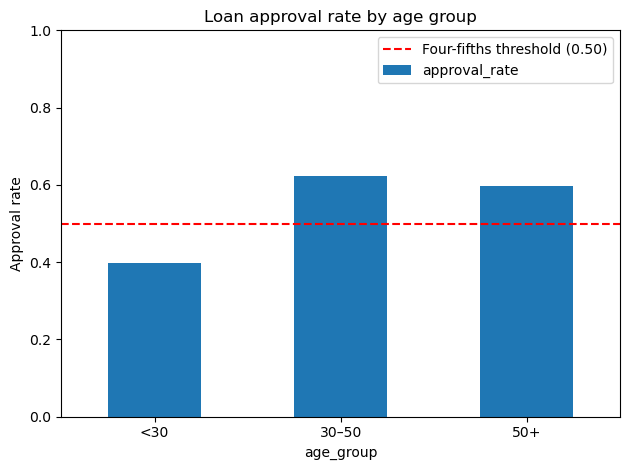

In [62]:
import matplotlib.pyplot as plt

threshold = 0.8 * rate_ref

fig, ax = plt.subplots()
approval_by_age["approval_rate"].plot(kind="bar", ax=ax, rot=0)

ax.set_ylabel("Approval rate")
ax.set_title("Loan approval rate by age group")
ax.set_ylim(0, 1)

ax.axhline(
    y=threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Four-fifths threshold ({threshold:.2f})"
)

ax.legend()
plt.tight_layout()
plt.show()

In [63]:
from scipy.stats import chi2_contingency

cont_age = pd.crosstab(df.loc[mask_age, "age_group"], df.loc[mask_age, decision_col])
display(cont_age)

chi2, p, dof, expected = chi2_contingency(cont_age)

# Cramér's V
n = cont_age.to_numpy().sum()
k = min(cont_age.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Chi-square test: Age Group vs Loan Approval")
print(f"Chi2 = {chi2:.4f}, p-value = {p:.6f}, dof = {dof}")
print(f"Cramer's V = {cramers_v:.3f}")
print("Result: Statistically significant association." if p < 0.05
      else "Result: No statistically significant association detected.")

decision.loan_approved,False,True
age_group,,
<30,41,27
30–50,77,127
50+,27,40


Chi-square test: Age Group vs Loan Approval
Chi2 = 10.8027, p-value = 0.004510, dof = 2
Cramer's V = 0.179
Result: Statistically significant association.


,avg_interest_rate,avg_approved_amount,n_approved
age_group,,,
<30,4.603704,44925.925926,27
30–50,4.560630,49086.614173,127
50+,4.432500,50250.000000,40


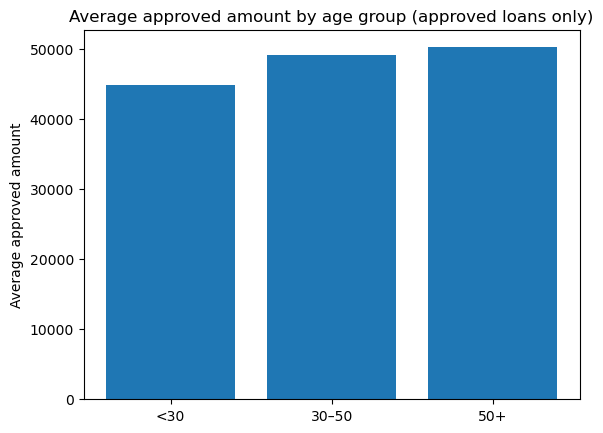

In [64]:
interest_col = "decision.interest_rate"
amount_col = "decision.approved_amount"

approved_mask = df["age_group"].notna() & (df[decision_col] == True)

missing = [c for c in [interest_col, amount_col] if c not in df.columns]
if missing:
    print(f"Skipping outcomes_by_age (missing columns): {missing}")
else:
    outcomes_by_age = (
        df.loc[approved_mask, ["age_group", interest_col, amount_col]]
          .groupby("age_group", observed=False)
          .agg(
              avg_interest_rate=(interest_col, "mean"),
              avg_approved_amount=(amount_col, "mean"),
              n_approved=(amount_col, "size"),
          )
    )
    display(outcomes_by_age)

    plt.figure()
    plt.bar(outcomes_by_age.index.astype(str), outcomes_by_age["avg_approved_amount"])
    plt.ylabel("Average approved amount")
    plt.title("Average approved amount by age group (approved loans only)")
    plt.show()

### Age-based Approval patterns

**Age Data Preparation**:

To assess potential age-related disparity in lending decisions, we derived an age variable from applicant_info.date_of_birth. Dates of birth were parsed to datetime (invalid or missing values become NaT), and age was computed using a fixed reference date for reproducibility. Applicants with missing DOB (and therefore missing age group) were excluded from age-based fairness metrics to avoid distorting group comparisons.


**Age Group Distribution**

We bucketed applicants into three age groups to enable stable comparisons:

• <30: 68 applicants

• 30–50: 204 applicants

• 50+: 67 applicants


**Aproval Rate Disparity**

Approval rates differ substantially across age groups:

• <30: 39.7%

• 30–50: 62.3%

• 50+: 59.7%

Treating 30-50 as the reference group, the Disparate Impact (DI) ratios are:

| Comparison   | DI Ratio | Below 0.80 threshold? |
| ------------ | -------: | :-------------------: |
| <30 vs 30–50 |    0.638 |          Yes          |
| 50+ vs 30–50 |    0.959 |           No          |

The primary disparity is between younger applicants (<30) and the other age groups. The under-30 group’s approval rate is only about 64% of the 30–50 group’s approval rate, which falls below the four-fifths (0.80) guideline and flags potential adverse impact for younger applicants.

**Statisticsl Test (Age Group vs Approval)**

To confirm the pattern is unlikely to be due to random variation, we ran a chi-square test of independence between age group and loan approval outcome. The test indicates a statistically significant association:

• χ² = 10.80, p = 0.00451, dof = 2

• Cramér’s V = 0.179 (small-to-moderate association)

This supports that approval outcomes vary by age group in this dataset (association evidence, not causal proof).


**Outcome Metrics Among Approved Applicants**

We also examined whether disparities extend beyond approval decisions to loan terms among approved applicants:

• Average interest rates are broadly similar across age groups (differences are small).

• Average approved amounts increase with age, with <30 receiving the lowest average approved amount and 50+ the highest.

This suggests the disparity is not only about who gets approved, but may also affect the scale of credit granted once approved.


**Possible Confounders**

Some of the observed differences may reflect age-correlated financial factors (e.g., shorter credit history for younger applicants, different income distributions, or higher debt-to-income ratios). These factors may contribute to approval differences even without direct age-based decision rules. However, if age-correlated variables act as proxies for age, they can still produce indirect age discrimination, which is why monitoring and governance controls are necessary.

**Sugested Mitigations**:

• Feature review: Evaluate age-correlated features (e.g., credit history months) and assess whether they create disproportionate impact on younger applicants.

• Regular monitoring: Track approval rates and DI ratios by age group over time, and trigger review if DI (<30 vs 30–50) remains below 0.80.

• Threshold review: If business rules or model thresholds create large age-group gaps, review whether adjustments are justified by risk evidence.

• Outcome monitoring: Monitor not only approval rates but also approved amounts by subgroup to detect “downstream” disparities in credit allocation.